# Systems of Linear Equations - Examples

Practical demonstrations of solving linear systems using NumPy.

## Topics Covered
1. Basic System Solving
2. Solution Types (Unique, Infinite, None)
3. Gaussian Elimination
4. LU Decomposition
5. Cholesky Decomposition
6. Linear Regression (Normal Equations)
7. Ridge Regression
8. Overdetermined Systems
9. Underdetermined Systems
10. Condition Number and Stability
11. Visualization

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg

np.set_printoptions(precision=4, suppress=True)

---
## 1. Basic Linear System

Solve the system:
$$\begin{cases}
x + 2y + z = 9 \\
2x - y + 3z = 8 \\
3x + y - z = 3
\end{cases}$$

In matrix form: $Ax = b$

In [5]:
# Coefficient matrix A and right-hand side b
A = np.array([[1, 2, 1],
              [2, -1, 3],
              [3, 1, -1]], dtype=float)

b = np.array([9, 8, 3], dtype=float)

print("System Ax = b:")
print(f"A =\n{A}")
print(f"b = {b}")

System Ax = b:
A =
[[ 1.  2.  1.]
 [ 2. -1.  3.]
 [ 3.  1. -1.]]
b = [9. 8. 3.]


In [6]:
# Method 1: np.linalg.solve (recommended)
x = np.linalg.solve(A, b)
print(f"Solution: x = {x}")

# Verify the solution
print(f"\nVerification: Ax = {A @ x}")
print(f"Residual ||Ax - b|| = {np.linalg.norm(A @ x - b):.2e}")

Solution: x = [1.08 2.56 2.8 ]

Verification: Ax = [9. 8. 3.]
Residual ||Ax - b|| = 4.44e-16


---
## 2. Different Solution Types

Linear systems can have:
1. **Unique solution**: rank(A) = rank([A|b]) = n
2. **No solution**: rank(A) < rank([A|b]) (inconsistent)
3. **Infinite solutions**: rank(A) = rank([A|b]) < n (dependent)

In [7]:
# 1. UNIQUE SOLUTION
print("1. UNIQUE SOLUTION")
A1 = np.array([[2, 1], [1, 3]])
b1 = np.array([5, 5])
x1 = np.linalg.solve(A1, b1)
print(f"   A = {A1.tolist()}, b = {b1.tolist()}")
print(f"   Solution: x = {x1}")
print(f"   rank(A) = {np.linalg.matrix_rank(A1)}")

1. UNIQUE SOLUTION
   A = [[2, 1], [1, 3]], b = [5, 5]
   Solution: x = [2. 1.]
   rank(A) = 2


In [8]:
# 2. NO SOLUTION (Parallel lines)
print("2. NO SOLUTION (Inconsistent - Parallel lines)")
A2 = np.array([[1, 1], [1, 1]])
b2 = np.array([2, 3])  # Different RHS
aug2 = np.column_stack([A2, b2])

print(f"   A = {A2.tolist()}, b = {b2.tolist()}")
print(f"   rank(A) = {np.linalg.matrix_rank(A2)}")
print(f"   rank([A|b]) = {np.linalg.matrix_rank(aug2)}")
print("   Since rank(A) < rank([A|b]), no solution exists!")

# Least squares "solution"
x2, residuals, rank, s = np.linalg.lstsq(A2, b2, rcond=None)
print(f"   Least squares approximation: {x2}")

2. NO SOLUTION (Inconsistent - Parallel lines)
   A = [[1, 1], [1, 1]], b = [2, 3]
   rank(A) = 1
   rank([A|b]) = 2
   Since rank(A) < rank([A|b]), no solution exists!
   Least squares approximation: [1.25 1.25]


In [9]:
# 3. INFINITE SOLUTIONS (Same line)
print("3. INFINITE SOLUTIONS (Dependent equations)")
A3 = np.array([[1, 2], [2, 4]])
b3 = np.array([3, 6])
aug3 = np.column_stack([A3, b3])

print(f"   A = {A3.tolist()}, b = {b3.tolist()}")
print(f"   rank(A) = {np.linalg.matrix_rank(A3)} < 2 unknowns")
print(f"   rank([A|b]) = {np.linalg.matrix_rank(aug3)}")
print("   Infinite solutions: x + 2y = 3, parameterized by y")
print("   Example solutions: (3, 0), (1, 1), (-1, 2), ...")

3. INFINITE SOLUTIONS (Dependent equations)
   A = [[1, 2], [2, 4]], b = [3, 6]
   rank(A) = 1 < 2 unknowns
   rank([A|b]) = 1
   Infinite solutions: x + 2y = 3, parameterized by y
   Example solutions: (3, 0), (1, 1), (-1, 2), ...


---
## 3. Gaussian Elimination (Step by Step)

Transform the augmented matrix [A|b] to row echelon form, then back-substitute.

In [10]:
# Augmented matrix [A | b]
aug = np.array([[1., 2., 1., 9.],
                [2., -1., 3., 8.],
                [3., 1., -1., 3.]])

print("Initial augmented matrix [A|b]:")
print(aug)

Initial augmented matrix [A|b]:
[[ 1.  2.  1.  9.]
 [ 2. -1.  3.  8.]
 [ 3.  1. -1.  3.]]


In [11]:
# Step 1: Eliminate first column below pivot
print("Step 1: R₂ ← R₂ - 2R₁, R₃ ← R₃ - 3R₁")
aug[1] = aug[1] - 2 * aug[0]
aug[2] = aug[2] - 3 * aug[0]
print(aug)

Step 1: R₂ ← R₂ - 2R₁, R₃ ← R₃ - 3R₁
[[  1.   2.   1.   9.]
 [  0.  -5.   1. -10.]
 [  0.  -5.  -4. -24.]]


In [12]:
# Step 2: Eliminate second column below pivot
print("Step 2: R₃ ← R₃ - R₂")
aug[2] = aug[2] - aug[1]
print(aug)
print("\n✓ Row Echelon Form achieved!")

Step 2: R₃ ← R₃ - R₂
[[  1.   2.   1.   9.]
 [  0.  -5.   1. -10.]
 [  0.   0.  -5. -14.]]

✓ Row Echelon Form achieved!


In [13]:
# Back substitution
print("Back substitution:")
z = aug[2, 3] / aug[2, 2]
y = (aug[1, 3] - aug[1, 2] * z) / aug[1, 1]
x = (aug[0, 3] - aug[0, 2] * z - aug[0, 1] * y) / aug[0, 0]

print(f"z = {aug[2,3]}/{aug[2,2]} = {z}")
print(f"y = ({aug[1,3]} - {aug[1,2]}*{z})/{aug[1,1]} = {y}")
print(f"x = ({aug[0,3]} - {aug[0,2]}*{z} - {aug[0,1]}*{y})/{aug[0,0]} = {x}")
print(f"\nSolution: x={x:.4f}, y={y:.4f}, z={z:.4f}")

Back substitution:
z = -14.0/-5.0 = 2.8
y = (-10.0 - 1.0*2.8)/-5.0 = 2.56
x = (9.0 - 1.0*2.8 - 2.0*2.56)/1.0 = 1.08

Solution: x=1.0800, y=2.5600, z=2.8000


---
## 4. LU Decomposition

Factor $A = PLU$ where:
- $P$ = permutation matrix
- $L$ = lower triangular
- $U$ = upper triangular

Advantages: Reuse factorization for multiple right-hand sides.

In [14]:
A = np.array([[2, 1, 1],
              [4, 3, 3],
              [8, 7, 9]], dtype=float)

print(f"Matrix A:\n{A}")

# LU decomposition with scipy
P, L, U = linalg.lu(A)

print(f"\nPermutation P:\n{P}")
print(f"\nLower triangular L:\n{L}")
print(f"\nUpper triangular U:\n{U}")

Matrix A:
[[2. 1. 1.]
 [4. 3. 3.]
 [8. 7. 9.]]

Permutation P:
[[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]

Lower triangular L:
[[1.     0.     0.    ]
 [0.25   1.     0.    ]
 [0.5    0.6667 1.    ]]

Upper triangular U:
[[ 8.      7.      9.    ]
 [ 0.     -0.75   -1.25  ]
 [ 0.      0.     -0.6667]]


In [15]:
# Verify: A = PLU
print(f"Verify: P @ L @ U =\n{P @ L @ U}")
print(f"Equals A: {np.allclose(P @ L @ U, A)}")

Verify: P @ L @ U =
[[2. 1. 1.]
 [4. 3. 3.]
 [8. 7. 9.]]
Equals A: True


In [16]:
# Solve Ax = b using LU
b = np.array([4, 10, 24])

# Using scipy's lu_factor and lu_solve
lu, piv = linalg.lu_factor(A)
x = linalg.lu_solve((lu, piv), b)

print(f"b = {b}")
print(f"Solution x = {x}")
print(f"Verify: Ax = {A @ x}")

b = [ 4 10 24]
Solution x = [1. 1. 1.]
Verify: Ax = [ 4. 10. 24.]


---
## 5. Cholesky Decomposition

For **symmetric positive definite** matrices: $A = LL^T$

- 2× faster than LU
- Numerically stable
- Common for covariance matrices, kernel matrices

In [17]:
# Create a symmetric positive definite matrix: A = X.T @ X
X = np.array([[2, 1],
              [1, 2],
              [1, 1]])
A = X.T @ X

print(f"Matrix A = XᵀX:\n{A}")
print(f"Is symmetric: {np.allclose(A, A.T)}")
print(f"Eigenvalues: {np.linalg.eigvalsh(A)} (all positive)")

Matrix A = XᵀX:
[[6 5]
 [5 6]]
Is symmetric: True
Eigenvalues: [ 1. 11.] (all positive)


In [18]:
# Cholesky decomposition: A = L @ L.T
L = np.linalg.cholesky(A)

print(f"Cholesky factor L:\n{L}")
print(f"\nVerify: L @ Lᵀ =\n{L @ L.T}")
print(f"Equals A: {np.allclose(L @ L.T, A)}")

Cholesky factor L:
[[2.4495 0.    ]
 [2.0412 1.354 ]]

Verify: L @ Lᵀ =
[[6. 5.]
 [5. 6.]]
Equals A: True


In [19]:
# Solve using Cholesky
b = np.array([10, 8])

# Forward solve: L @ y = b
y = linalg.solve_triangular(L, b, lower=True)
# Backward solve: L.T @ x = y
x = linalg.solve_triangular(L.T, y, lower=False)

print(f"b = {b}")
print(f"Solution x = {x}")
print(f"Verify: Ax = {A @ x}")

b = [10  8]
Solution x = [ 1.8182 -0.1818]
Verify: Ax = [10.  8.]


---
## 6. Linear Regression (Normal Equations)

Least squares solution minimizes $\|X\mathbf{w} - \mathbf{y}\|^2$

**Normal equations:** $(X^TX)\mathbf{w} = X^T\mathbf{y}$

**Solution:** $\mathbf{w} = (X^TX)^{-1}X^T\mathbf{y}$

In [20]:
np.random.seed(42)

# Generate data: y = 2 + 3*x + noise
n = 50
x = np.random.uniform(0, 10, n)
y = 2 + 3 * x + np.random.randn(n) * 2

# Design matrix [1, x]
X = np.column_stack([np.ones(n), x])

print(f"Data: {n} points")
print(f"Design matrix X shape: {X.shape}")
print(f"True parameters: w₀=2, w₁=3")

Data: 50 points
Design matrix X shape: (50, 2)
True parameters: w₀=2, w₁=3


In [21]:
# Normal equations: (XᵀX)w = Xᵀy
XtX = X.T @ X
Xty = X.T @ y

print(f"XᵀX =\n{XtX}")
print(f"\nXᵀy = {Xty}")

# Solve
w = np.linalg.solve(XtX, Xty)
print(f"\nEstimated parameters: w₀={w[0]:.4f}, w₁={w[1]:.4f}")

# Compare with numpy's lstsq
w_lstsq, residuals, rank, s = np.linalg.lstsq(X, y, rcond=None)
print(f"Using lstsq: w₀={w_lstsq[0]:.4f}, w₁={w_lstsq[1]:.4f}")

XᵀX =
[[  50.      222.962 ]
 [ 222.962  1403.1628]]

Xᵀy = [ 768.5913 4635.8255]

Estimated parameters: w₀=2.1934, w₁=2.9553
Using lstsq: w₀=2.1934, w₁=2.9553


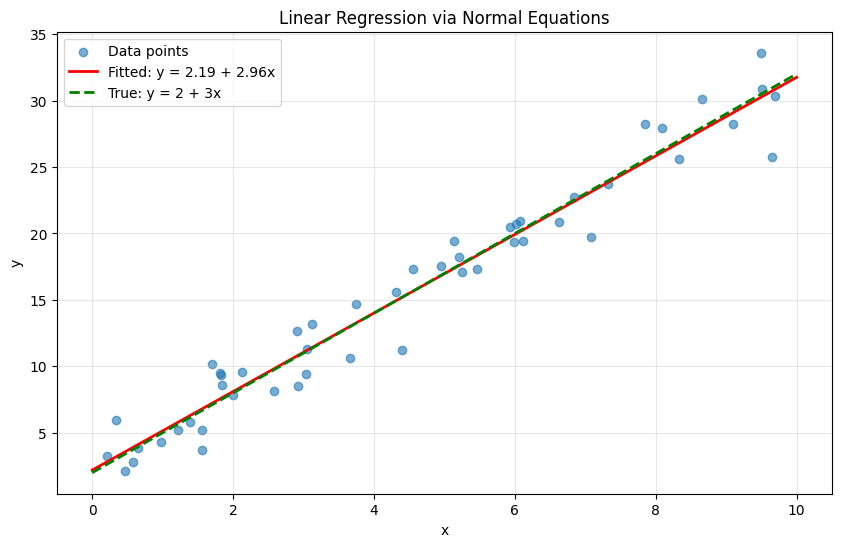

In [22]:
# Visualize
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6, label='Data points')
x_line = np.linspace(0, 10, 100)
plt.plot(x_line, w[0] + w[1] * x_line, 'r-', linewidth=2, 
         label=f'Fitted: y = {w[0]:.2f} + {w[1]:.2f}x')
plt.plot(x_line, 2 + 3 * x_line, 'g--', linewidth=2, 
         label='True: y = 2 + 3x')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression via Normal Equations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## 7. Ridge Regression (Regularization)

When $X^TX$ is ill-conditioned, add regularization:

$$\mathbf{w} = (X^TX + \lambda I)^{-1}X^T\mathbf{y}$$

This improves numerical stability and reduces overfitting.

In [23]:
np.random.seed(42)

# Create an ill-conditioned system (nearly collinear features)
n, d = 100, 5
X = np.random.randn(n, d)
X[:, 1] = X[:, 0] + 0.01 * np.random.randn(n)  # Nearly collinear
X[:, 2] = X[:, 0] + X[:, 1] + 0.01 * np.random.randn(n)

true_w = np.array([1, 2, 3, 4, 5])
y = X @ true_w + np.random.randn(n) * 0.1

# Check condition number
XtX = X.T @ X
cond = np.linalg.cond(XtX)
print(f"Condition number of XᵀX: {cond:.2e}")
print("(Large condition number = ill-conditioned)")

Condition number of XᵀX: 1.42e+05
(Large condition number = ill-conditioned)


In [24]:
# Ordinary least squares (may be unstable)
w_ols = np.linalg.lstsq(X, y, rcond=None)[0]
print(f"OLS solution: {w_ols}")

# Ridge regression: (XᵀX + λI)w = Xᵀy
lambda_reg = 0.1
XtX_reg = XtX + lambda_reg * np.eye(d)
w_ridge = np.linalg.solve(XtX_reg, X.T @ y)

print(f"\nRidge (λ={lambda_reg}) solution: {w_ridge}")
print(f"True weights: {true_w}")
print(f"\nRegularized condition number: {np.linalg.cond(XtX_reg):.2e}")

OLS solution: [0.9213 3.7502 2.1651 3.9994 5.0048]

Ridge (λ=0.1) solution: [1.4709 1.5984 2.9651 3.996  5.0013]
True weights: [1 2 3 4 5]

Regularized condition number: 4.70e+03


---
## 8. Overdetermined Systems (Least Squares)

More equations than unknowns → No exact solution.

Find the solution that minimizes the residual $\|Ax - b\|^2$.

In [25]:
# Fit a quadratic: y = a + bx + cx² to 10 data points
x = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
y = np.array([1.0, 1.8, 1.3, 3.4, 4.2, 5.8, 7.1, 7.9, 9.4, 10.2])

# Design matrix for quadratic fit
X = np.column_stack([np.ones_like(x), x, x**2])

print(f"Points: {len(x)}")
print(f"Design matrix shape: {X.shape} (overdetermined: 10 equations, 3 unknowns)")

# Least squares solution
coeffs, residuals, rank, s = np.linalg.lstsq(X, y, rcond=None)

print(f"\nFitted coefficients: a={coeffs[0]:.4f}, b={coeffs[1]:.4f}, c={coeffs[2]:.4f}")
print(f"Model: y = {coeffs[0]:.4f} + {coeffs[1]:.4f}x + {coeffs[2]:.4f}x²")

# Prediction
y_pred = X @ coeffs
mse = np.mean((y - y_pred) ** 2)
print(f"Mean Squared Error: {mse:.4f}")

Points: 10
Design matrix shape: (10, 3) (overdetermined: 10 equations, 3 unknowns)

Fitted coefficients: a=0.6591, b=0.7978, c=0.0337
Model: y = 0.6591 + 0.7978x + 0.0337x²
Mean Squared Error: 0.1904


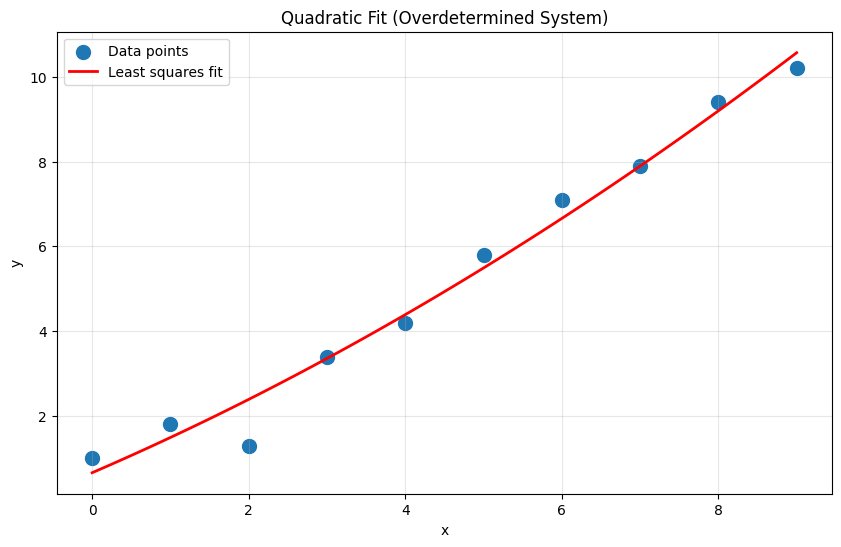

In [26]:
# Visualize
plt.figure(figsize=(10, 6))
plt.scatter(x, y, s=100, label='Data points')
x_fine = np.linspace(0, 9, 100)
y_fine = coeffs[0] + coeffs[1] * x_fine + coeffs[2] * x_fine**2
plt.plot(x_fine, y_fine, 'r-', linewidth=2, label='Least squares fit')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Quadratic Fit (Overdetermined System)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## 9. Underdetermined Systems

Fewer equations than unknowns → Infinite solutions.

The **minimum norm solution** has the smallest $\|x\|$.

In [27]:
# 2 equations, 4 unknowns
A = np.array([[1, 2, 1, 0],
              [0, 1, 1, 1]])
b = np.array([4, 3])

print(f"System: 2 equations, 4 unknowns")
print(f"A =\n{A}")
print(f"b = {b}")

System: 2 equations, 4 unknowns
A =
[[1 2 1 0]
 [0 1 1 1]]
b = [4 3]


In [28]:
# Minimum norm solution (using pseudo-inverse)
x_min_norm = np.linalg.lstsq(A, b, rcond=None)[0]

print(f"Minimum norm solution: {x_min_norm}")
print(f"||x||² = {np.linalg.norm(x_min_norm)**2:.4f}")
print(f"Verify: Ax = {A @ x_min_norm}")

# Null space
null_space = linalg.null_space(A)
print(f"\nNull space dimension: {null_space.shape[1]}")
print(f"Null space vectors:\n{null_space}")

Minimum norm solution: [0.3333 1.3333 1.     0.6667]
||x||² = 3.3333
Verify: Ax = [4. 3.]

Null space dimension: 2
Null space vectors:
[[ 0.1133  0.8086]
 [-0.4609 -0.3477]
 [ 0.8086 -0.1133]
 [-0.3477  0.4609]]


In [29]:
# Alternative solution: add null space vectors
x_alt = x_min_norm + null_space @ np.array([1, 1])

print(f"Alternative solution: {x_alt}")
print(f"||x_alt||² = {np.linalg.norm(x_alt)**2:.4f} (larger than min norm)")
print(f"Verify: Ax_alt = {A @ x_alt}")

Alternative solution: [1.2552 0.5247 1.6953 0.7799]
||x_alt||² = 5.3333 (larger than min norm)
Verify: Ax_alt = [4. 3.]


---
## 10. Condition Number and Stability

The **condition number** $\kappa(A)$ measures sensitivity to perturbations:
- $\kappa \approx 1$: Well-conditioned
- $\kappa \gg 1$: Ill-conditioned (small errors amplified)

In [30]:
# Well-conditioned matrix
A_good = np.array([[1, 0], [0, 1]], dtype=float)
b_good = np.array([1, 1], dtype=float)

# Ill-conditioned matrix (Hilbert matrix)
A_bad = np.array([[1, 1/2], [1/2, 1/3]], dtype=float)
b_bad = np.array([1, 1], dtype=float)

print("Well-conditioned system (Identity):")
print(f"  Condition number: {np.linalg.cond(A_good):.2f}")

print("\nIll-conditioned system (Hilbert 2×2):")
print(f"  Condition number: {np.linalg.cond(A_bad):.2f}")

Well-conditioned system (Identity):
  Condition number: 1.00

Ill-conditioned system (Hilbert 2×2):
  Condition number: 19.28


In [31]:
# Solve both
x_good = np.linalg.solve(A_good, b_good)
x_bad = np.linalg.solve(A_bad, b_bad)

print(f"Solutions:")
print(f"  Well-conditioned: {x_good}")
print(f"  Ill-conditioned: {x_bad}")

# Perturb b slightly
epsilon = 0.01
b_good_perturbed = b_good + epsilon * np.array([1, 0])
b_bad_perturbed = b_bad + epsilon * np.array([1, 0])

x_good_perturbed = np.linalg.solve(A_good, b_good_perturbed)
x_bad_perturbed = np.linalg.solve(A_bad, b_bad_perturbed)

print(f"\nAfter perturbing b by {epsilon}:")
print(f"  Well-conditioned solution change: {np.linalg.norm(x_good_perturbed - x_good):.4f}")
print(f"  Ill-conditioned solution change: {np.linalg.norm(x_bad_perturbed - x_bad):.4f}")
print("\n  ⚠️ Ill-conditioned systems amplify small errors!")

Solutions:
  Well-conditioned: [1. 1.]
  Ill-conditioned: [-2.  6.]

After perturbing b by 0.01:
  Well-conditioned solution change: 0.0100
  Ill-conditioned solution change: 0.0721

  ⚠️ Ill-conditioned systems amplify small errors!


---
## 11. Visualization: 2D Linear Systems

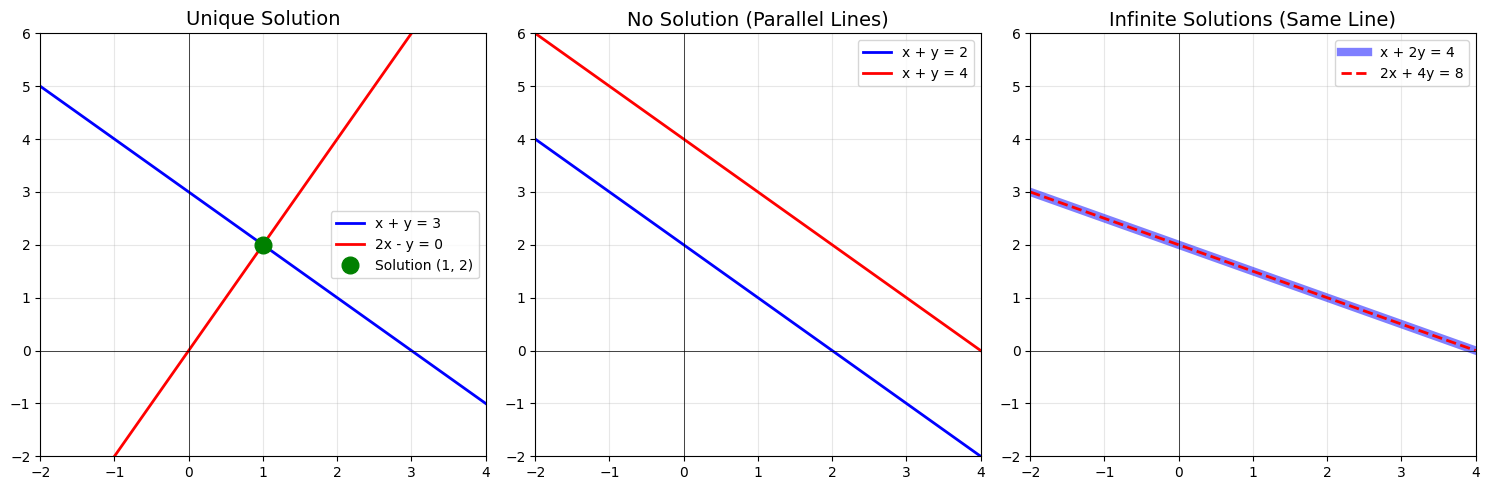

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
x_range = np.linspace(-2, 4, 100)

# 1. Unique solution
ax = axes[0]
ax.plot(x_range, 3 - x_range, 'b-', linewidth=2, label='x + y = 3')
ax.plot(x_range, 2 * x_range, 'r-', linewidth=2, label='2x - y = 0')
ax.plot(1, 2, 'go', markersize=12, label='Solution (1, 2)')
ax.set_xlim(-2, 4)
ax.set_ylim(-2, 6)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.grid(True, alpha=0.3)
ax.set_title('Unique Solution', fontsize=14)
ax.legend()

# 2. No solution (parallel lines)
ax = axes[1]
ax.plot(x_range, 2 - x_range, 'b-', linewidth=2, label='x + y = 2')
ax.plot(x_range, 4 - x_range, 'r-', linewidth=2, label='x + y = 4')
ax.set_xlim(-2, 4)
ax.set_ylim(-2, 6)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.grid(True, alpha=0.3)
ax.set_title('No Solution (Parallel Lines)', fontsize=14)
ax.legend()

# 3. Infinite solutions (same line)
ax = axes[2]
ax.plot(x_range, (4 - x_range) / 2, 'b-', linewidth=6, alpha=0.5, label='x + 2y = 4')
ax.plot(x_range, (4 - x_range) / 2, 'r--', linewidth=2, label='2x + 4y = 8')
ax.set_xlim(-2, 4)
ax.set_ylim(-2, 6)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.grid(True, alpha=0.3)
ax.set_title('Infinite Solutions (Same Line)', fontsize=14)
ax.legend()

plt.tight_layout()
plt.show()

---
## Summary

| Method | Use Case | Complexity |
|--------|----------|------------|
| `np.linalg.solve` | General systems | $O(n^3)$ |
| LU Decomposition | Multiple right-hand sides | $O(n^3)$ once |
| Cholesky | Symmetric positive definite | $O(n^3/3)$ |
| `np.linalg.lstsq` | Overdetermined systems | $O(mn^2)$ |
| Ridge regression | Ill-conditioned systems | $O(n^3)$ |

**Key Takeaways:**
1. Always check solution type (unique, infinite, none)
2. Use `np.linalg.solve`, never invert matrices explicitly
3. Check condition number for stability
4. Use regularization for ill-conditioned problems